In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries loaded ✅")

All libraries loaded ✅


In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nAttrition Distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.2f}%")
df.head(3)

Dataset Shape: (1470, 35)

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [3]:
print("=== MISSING VALUES ===")
print(df.isnull().sum().sum())

print("\n=== CONSTANT COLUMNS (no value) ===")
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns: {constant_cols}")

# Constant columns drop karo
df = df.drop(columns=constant_cols)

# Attrition binary karo
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print(f"\nCleaned Dataset Shape: {df.shape}")
print("Data Cleaning Done ✅")

=== MISSING VALUES ===
0

=== CONSTANT COLUMNS (no value) ===
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']

Cleaned Dataset Shape: (1470, 32)
Data Cleaning Done ✅


In [4]:
# Age groups
df['AgeGroup'] = pd.cut(df['Age'], 
                         bins=[18, 25, 35, 45, 60],
                         labels=['18-25', '26-35', '36-45', '46-60'])

# Experience groups
df['ExperienceGroup'] = pd.cut(df['TotalWorkingYears'],
                                bins=[0, 5, 10, 20, 40],
                                labels=['0-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs'])

# Salary groups
df['SalaryGroup'] = pd.cut(df['MonthlyIncome'],
                            bins=[0, 3000, 6000, 10000, 20000],
                            labels=['Low', 'Medium', 'High', 'Very High'])

print("Feature Engineering Done ✅")
print(f"\nAge Groups:\n{df['AgeGroup'].value_counts()}")

Feature Engineering Done ✅

Age Groups:
AgeGroup
26-35    606
36-45    468
46-60    273
18-25    115
Name: count, dtype: int64


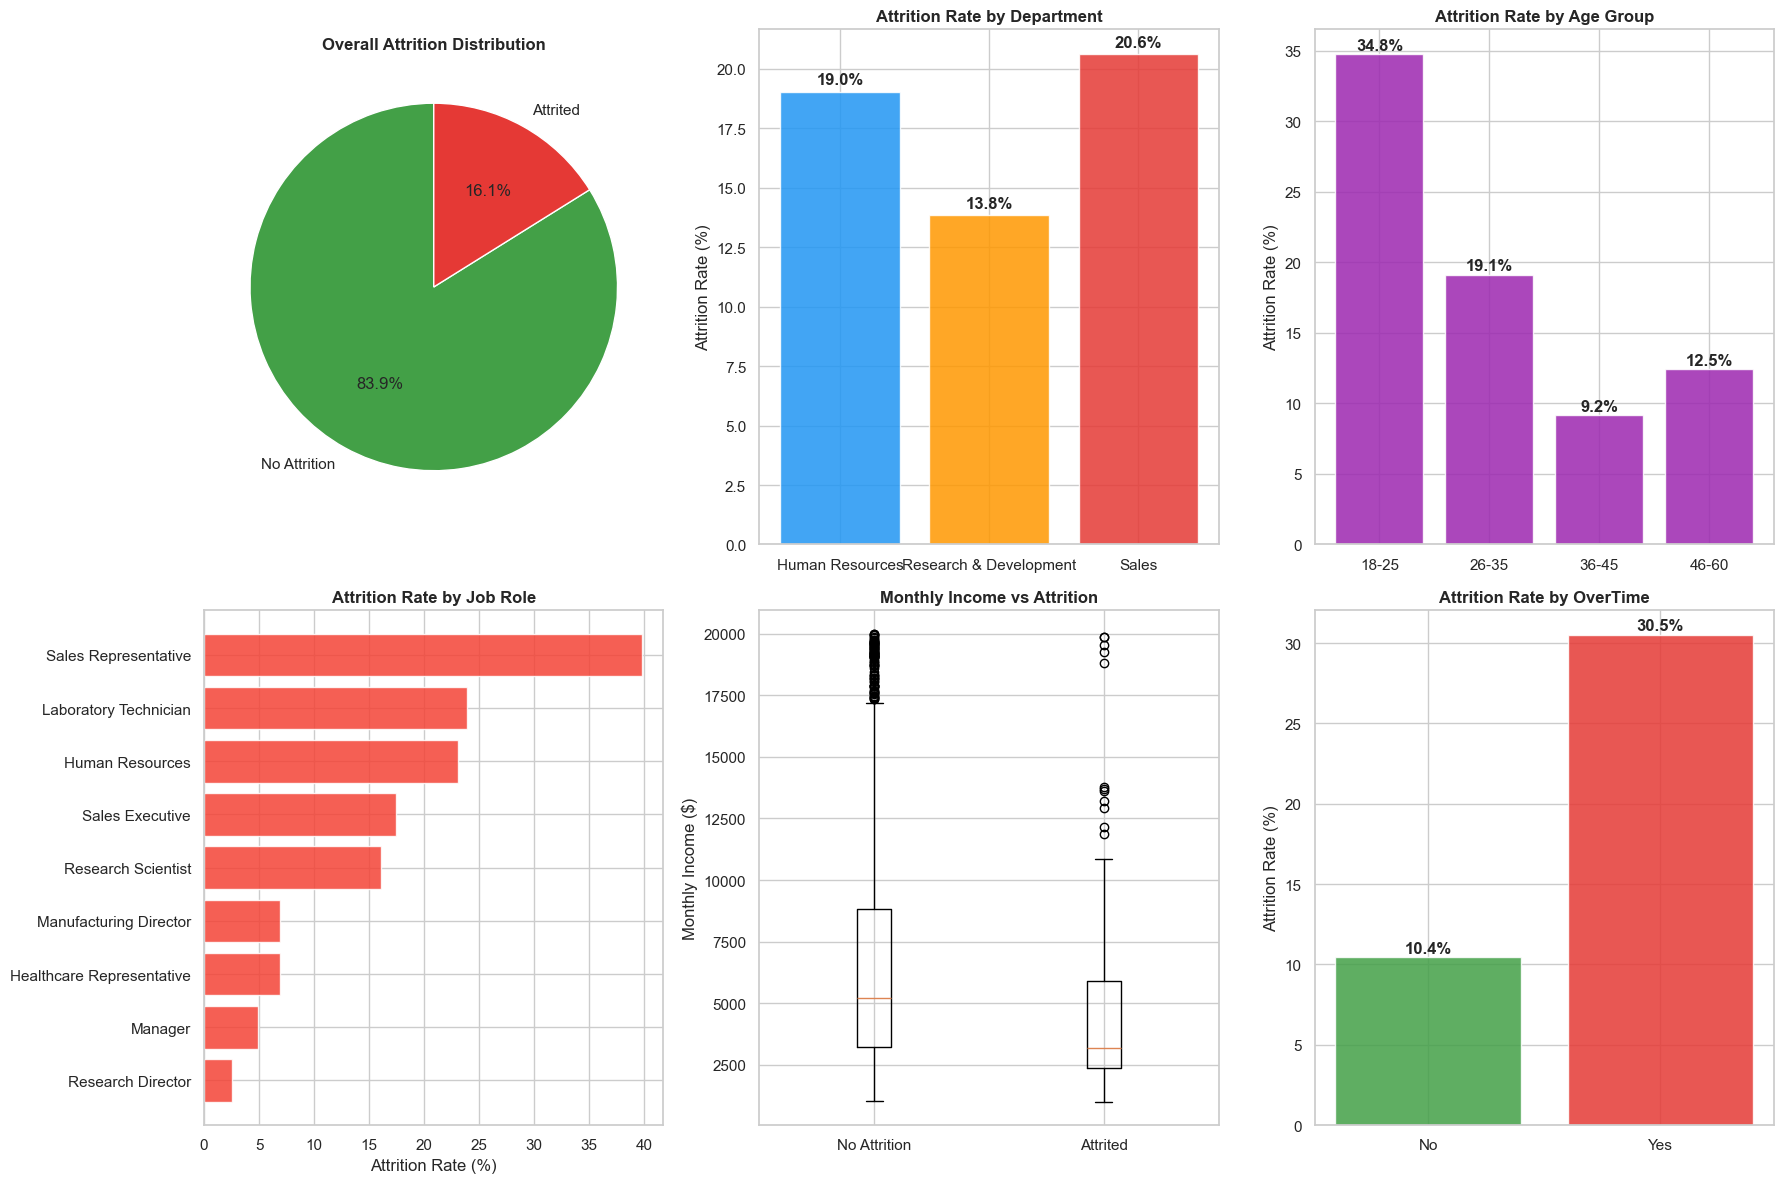

HR Visualizations saved ✅


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1 - Attrition Distribution
attrition_counts = df['Attrition'].value_counts()
axes[0,0].pie(attrition_counts, labels=['No Attrition', 'Attrited'],
              autopct='%1.1f%%', colors=['#43A047','#E53935'],
              startangle=90)
axes[0,0].set_title('Overall Attrition Distribution', fontweight='bold')

# Plot 2 - Attrition by Department
dept_attr = df.groupby('Department')['Attrition'].mean() * 100
axes[0,1].bar(dept_attr.index, dept_attr.values,
              color=['#2196F3','#FF9800','#E53935'], alpha=0.85)
axes[0,1].set_title('Attrition Rate by Department', fontweight='bold')
axes[0,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(dept_attr.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3 - Attrition by Age Group
age_attr = df.groupby('AgeGroup', observed=True)['Attrition'].mean() * 100
axes[0,2].bar(age_attr.index, age_attr.values, color='#9C27B0', alpha=0.85)
axes[0,2].set_title('Attrition Rate by Age Group', fontweight='bold')
axes[0,2].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(age_attr.values):
    axes[0,2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 4 - Attrition by Job Role
role_attr = df.groupby('JobRole')['Attrition'].mean() * 100
role_attr = role_attr.sort_values(ascending=True)
axes[1,0].barh(role_attr.index, role_attr.values, color='#F44336', alpha=0.85)
axes[1,0].set_title('Attrition Rate by Job Role', fontweight='bold')
axes[1,0].set_xlabel('Attrition Rate (%)')

# Plot 5 - Monthly Income vs Attrition
axes[1,1].boxplot([df[df['Attrition']==0]['MonthlyIncome'],
                   df[df['Attrition']==1]['MonthlyIncome']],
                   labels=['No Attrition', 'Attrited'])
axes[1,1].set_title('Monthly Income vs Attrition', fontweight='bold')
axes[1,1].set_ylabel('Monthly Income ($)')

# Plot 6 - Overtime vs Attrition
ot_attr = df.groupby('OverTime')['Attrition'].mean() * 100
axes[1,2].bar(ot_attr.index, ot_attr.values,
              color=['#43A047', '#E53935'], alpha=0.85)
axes[1,2].set_title('Attrition Rate by OverTime', fontweight='bold')
axes[1,2].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(ot_attr.values):
    axes[1,2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/hr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("HR Visualizations saved ✅")

In [6]:
# SQL jaisi queries Python mein — yahi interview mein poochha jaata hai

print("=" * 55)
print("       SQL-STYLE HR ANALYTICS QUERIES")
print("=" * 55)

# Query 1 - Department wise headcount aur attrition
print("\n📊 Q1: Department-wise Headcount & Attrition Rate")
dept_summary = df.groupby('Department').agg(
    Total_Employees=('Attrition', 'count'),
    Attrited=('Attrition', 'sum'),
    Attrition_Rate=('Attrition', lambda x: f"{x.mean()*100:.1f}%"),
    Avg_Salary=('MonthlyIncome', lambda x: f"${x.mean():,.0f}"),
    Avg_Age=('Age', 'mean')
).reset_index()
print(dept_summary.to_string(index=False))

# Query 2 - Top 5 high risk job roles
print("\n📊 Q2: Top 5 High Attrition Risk Job Roles")
role_risk = df.groupby('JobRole').agg(
    Total=('Attrition', 'count'),
    Attrited=('Attrition', 'sum'),
    Risk_Rate=('Attrition', lambda x: round(x.mean()*100, 1))
).reset_index().sort_values('Risk_Rate', ascending=False).head(5)
print(role_risk.to_string(index=False))

# Query 3 - Overtime impact
print("\n📊 Q3: Overtime Impact on Attrition")
ot_impact = df.groupby('OverTime').agg(
    Total=('Attrition', 'count'),
    Attrited=('Attrition', 'sum'),
    Attrition_Rate=('Attrition', lambda x: f"{x.mean()*100:.1f}%"),
    Avg_Salary=('MonthlyIncome', lambda x: f"${x.mean():,.0f}")
).reset_index()
print(ot_impact.to_string(index=False))

# Query 4 - Salary band analysis
print("\n📊 Q4: Attrition by Salary Band")
sal_analysis = df.groupby('SalaryGroup', observed=True).agg(
    Total=('Attrition', 'count'),
    Attrited=('Attrition', 'sum'),
    Attrition_Rate=('Attrition', lambda x: f"{x.mean()*100:.1f}%")
).reset_index()
print(sal_analysis.to_string(index=False))

# Query 5 - Experience vs Attrition
print("\n📊 Q5: Experience Group vs Attrition")
exp_analysis = df.groupby('ExperienceGroup', observed=True).agg(
    Total=('Attrition', 'count'),
    Attrited=('Attrition', 'sum'),
    Attrition_Rate=('Attrition', lambda x: f"{x.mean()*100:.1f}%"),
    Avg_Salary=('MonthlyIncome', lambda x: f"${x.mean():,.0f}")
).reset_index()
print(exp_analysis.to_string(index=False))

print("\n✅ SQL-Style Queries Complete!")

       SQL-STYLE HR ANALYTICS QUERIES

📊 Q1: Department-wise Headcount & Attrition Rate
            Department  Total_Employees  Attrited Attrition_Rate Avg_Salary   Avg_Age
       Human Resources               63        12          19.0%     $6,655 37.809524
Research & Development              961       133          13.8%     $6,281 37.042664
                 Sales              446        92          20.6%     $6,959 36.542601

📊 Q2: Top 5 High Attrition Risk Job Roles
              JobRole  Total  Attrited  Risk_Rate
 Sales Representative     83        33       39.8
Laboratory Technician    259        62       23.9
      Human Resources     52        12       23.1
      Sales Executive    326        57       17.5
   Research Scientist    292        47       16.1

📊 Q3: Overtime Impact on Attrition
OverTime  Total  Attrited Attrition_Rate Avg_Salary
      No   1054       110          10.4%     $6,485
     Yes    416       127          30.5%     $6,549

📊 Q4: Attrition by Salary Band
S

In [7]:
# Streamlit dashboard ke liye processed data save karo
df.to_csv('../data/hr_processed.csv', index=False)

# Summary tables save karo
dept_summary.to_csv('../data/dept_summary.csv', index=False)
role_risk.to_csv('../data/role_risk.csv', index=False)

# Excel report banao
with pd.ExcelWriter('../reports/HR_Analytics_Report.xlsx', engine='openpyxl') as writer:
    dept_summary.to_excel(writer, sheet_name='Department Summary', index=False)
    role_risk.to_excel(writer, sheet_name='High Risk Roles', index=False)
    ot_impact.to_excel(writer, sheet_name='Overtime Impact', index=False)
    sal_analysis.to_excel(writer, sheet_name='Salary Analysis', index=False)
    exp_analysis.to_excel(writer, sheet_name='Experience Analysis', index=False)

print("✅ All files exported!")
print("   - hr_processed.csv")
print("   - dept_summary.csv")
print("   - role_risk.csv")
print("   - HR_Analytics_Report.xlsx")

✅ All files exported!
   - hr_processed.csv
   - dept_summary.csv
   - role_risk.csv
   - HR_Analytics_Report.xlsx
